In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [11]:
df = pd.read_csv('/Users/Devika/Desktop/IronHack/Week5/Project2/df_final_demo.txt', sep=',')

In [13]:
df.to_csv('/Users/Devika/Desktop/IronHack/Week5/Project2/df_final_demo.csv', index=False)


In [15]:
df.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [17]:
# 1. Demo
df_demo = pd.read_csv('/Users/Devika/Desktop/IronHack/Week5/Project2/df_final_demo.txt', sep=',')
df_demo.to_csv('/Users/Devika/Desktop/IronHack/Week5/Project2/df_final_demo.csv', index=False)

# 2. Experiment Clients
df_experiment = pd.read_csv('/Users/Devika/Desktop/IronHack/Week5/Project2/df_final_experiment_clients.txt', sep=',')
df_experiment.to_csv('/Users/Devika/Desktop/IronHack/Week5/Project2/df_final_experiment_clients.csv', index=False)

# 3. Web Data Part 1
df_pt1 = pd.read_csv('/Users/Devika/Desktop/IronHack/Week5/Project2/df_final_web_data_pt_1.txt', sep=',')
df_pt1.to_csv('/Users/Devika/Desktop/IronHack/Week5/Project2/df_final_web_data_pt_1.csv', index=False)

# 4. Web Data Part 2
df_pt2 = pd.read_csv('/Users/Devika/Desktop/IronHack/Week5/Project2/df_final_web_data_pt_2.txt', sep=',')
df_pt2.to_csv('/Users/Devika/Desktop/IronHack/Week5/Project2/df_final_web_data_pt_2.csv', index=False)

# ✅ Optional: Confirm
print("All files converted to CSV successfully!")

All files converted to CSV successfully!


In [21]:
import pandas as pd

# Load the two parts
df_pt1 = pd.read_csv('/Users/Devika/Desktop/IronHack/Week5/Project2/df_final_web_data_pt_1.csv')
df_pt2 = pd.read_csv('/Users/Devika/Desktop/IronHack/Week5/Project2/df_final_web_data_pt_2.csv')

# Merge them together
df_web = pd.concat([df_pt1, df_pt2], axis=0, ignore_index=True)

# Optional: View the shape and first rows
print(f"Combined shape: {df_web.shape}")
df_web.head()

Combined shape: (755405, 5)


,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [23]:
df_web.isnull().sum()

client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64

In [25]:
# Show only columns with missing values
missing = df_web.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

In [27]:
df_web['date_time'] = pd.to_datetime(df_web['date_time'], errors='coerce')

In [29]:
df_web.dropna(subset=['date_time'], inplace=True)

In [31]:
df_web['date_time'].isnull().sum()

0

In [33]:
df_web = df_web.drop_duplicates()

In [35]:
df_web = df_web.drop_duplicates(subset='client_id')

In [37]:
df_web = df_web.drop_duplicates(subset=['client_id', 'date_time'])

In [39]:
print(f"Remaining rows: {df_web.shape[0]}")

Remaining rows: 120157


In [41]:
df_demo.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [43]:
df_demo.columns.tolist()

['client_id',
 'clnt_tenure_yr',
 'clnt_tenure_mnth',
 'clnt_age',
 'gendr',
 'num_accts',
 'bal',
 'calls_6_mnth',
 'logons_6_mnth']

In [20]:
df_demo = df_demo.rename(columns={
    "client_id": "Client_id",
    "clnt_tenure_yr": "Client_tenure_year",
    "clnt_tenure_mnth": "Client_tenure_month",
    "clnt_age": "Client_age",
    "gendr": "Gender",
    "num_accts": "Number_of_accounts",
    "bal": "Balance",
    "calls_6_mnth": "Calls_six_month",
    "logons_6_mnth": "Logins_six_month"
})

In [22]:
print(df_demo.columns.tolist())

['Client_id', 'Client_tenure_year', 'Client_tenure_month', 'Client_age', 'Gender', 'Number_of_accounts', 'Balance', 'Calls_six_month', 'Logins_six_month']


In [49]:
df_demo.isnull().sum()

Client_id               0
Client_tenure_year     14
Client_tenure_month    14
Client_age             15
Gender                 14
Number_of_accounts     14
Balance                14
Calls_six_month        14
Logins_six_month       14
dtype: int64

In [51]:
df_demo.dropna(subset=['Client_id', 'Client_age', 'Gender'], inplace=True)

In [53]:
# Use the median to fill missing values — this avoids the impact of outliers:

df_demo["Balance"] = df_demo["Balance"].fillna(df_demo["Balance"].median())
df_demo["Client_tenure_year"] = df_demo["Client_tenure_year"].fillna(df_demo["Client_tenure_year"].median())
df_demo["Client_tenure_month"] = df_demo["Client_tenure_month"].fillna(df_demo["Client_tenure_month"].median())
df_demo["Client_age"] = df_demo["Client_age"].fillna(df_demo["Client_age"].median())
df_demo["Number_of_accounts"] = df_demo["Number_of_accounts"].fillna(df_demo["Number_of_accounts"].median())
df_demo["Calls_six_month"] = df_demo["Calls_six_month"].fillna(df_demo["Calls_six_month"].median())
df_demo["Logins_six_month"] = df_demo["Logins_six_month"].fillna(df_demo["Logins_six_month"].median())


In [55]:
# Use the mode to fill the most frequent category (e.g. M or F):
df_demo["Gender"] = df_demo["Gender"].fillna(df_demo["Gender"].mode()[0])


In [57]:
for col in ["Balance", "Client_tenure_year", "Client_tenure_month", "Client_age",
            "Number_of_accounts", "Calls_six_month", "Logins_six_month"]:
    if col in df_demo.columns:
        df_demo[col] = df_demo[col].fillna(df_demo[col].median())

if "Gender" in df_demo.columns:
    df_demo["Gender"] = df_demo["Gender"].fillna(df_demo["Gender"].mode()[0])

In [59]:
unique_genders = df_demo['Gender'].unique()
unique_genders

array(['U', 'M', 'F', 'X'], dtype=object)

In [61]:
gender_counts = df_demo['Gender'].value_counts()
gender_counts

Gender
U    24122
M    23724
F    22745
X        3
Name: count, dtype: int64

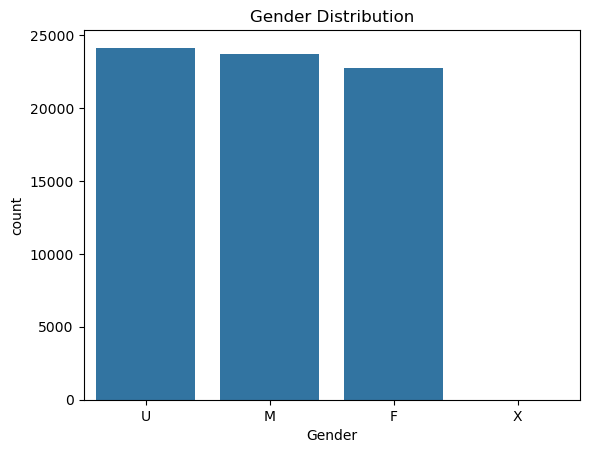

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df_demo, x='Gender')
plt.title('Gender Distribution')
plt.show()

In [65]:
# Filter to only valid gender values
df_filtered = df_demo[df_demo['Gender'].isin(['M', 'F', 'U'])]

# Check what's left
print("Unique genders after filtering:", df_filtered['Gender'].unique())
print("\nCount of remaining genders:")
print(df_filtered['Gender'].value_counts())


Unique genders after filtering: ['U' 'M' 'F']

Count of remaining genders:
Gender
U    24122
M    23724
F    22745
Name: count, dtype: int64


In [67]:
df_experiment.head()

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control


In [69]:
print(df_experiment.isnull().sum())

client_id        0
Variation    20109
dtype: int64


In [71]:
print(df_experiment.shape[0])

70609


In [73]:
# drop rows with missing values
df_experiment=df_experiment.dropna(subset=["Variation"]).copy()

In [75]:
#confirm its clean
print("Remaining rows:", df_experiment.shape[0])
print("Missing values:\n", df_experiment.isnull().sum())

Remaining rows: 50500
Missing values:
 client_id    0
Variation    0
dtype: int64


In [77]:
# check grouo count
print("Variation group counts:\n", df_experiment["Variation"].value_counts())

Variation group counts:
 Variation
Test       26968
Control    23532
Name: count, dtype: int64


In [79]:
# check grouo count
print("Variation group counts:\n", df_experiment["Variation"].value_counts())

Variation group counts:
 Variation
Test       26968
Control    23532
Name: count, dtype: int64


In [41]:
# Gender distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df_filtered, x='Gender')
plt.title('Gender Distribution of Clients')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()


NameError: name 'df_filtered' is not defined

<Figure size 600x400 with 0 Axes>

In [83]:
#This will help answer:who are the primary clients?
#are they younger or older
#is there a diminant gender?
#how long have they had account?

In [85]:
#completion rate
# Define final step name
final_step = 'confirm'

# Users who reached final step
completed = df_web[df_web['process_step'] == final_step]['client_id'].nunique()
total_users = df_web['client_id'].nunique()

completion_rate = completed / total_users
print(f"Completion Rate: {completion_rate:.2%}")

Completion Rate: 57.94%


In [87]:
#time spend on each step
# Step 1: Convert to datetime
df_web['date_time'] = pd.to_datetime(df_web['date_time'], errors='coerce')

# Step 2: Sort within each visit
df_web = df_web.sort_values(by=['visit_id', 'date_time'])

# Step 3: Compute time between steps within each visit
df_web['step_duration'] = df_web.groupby('visit_id')['date_time'].diff()

# Step 4: Average duration per step
avg_time_per_step = df_web.groupby('process_step')['step_duration'].mean().reset_index()

# Optional: Convert to minutes
avg_time_per_step['duration_minutes'] = avg_time_per_step['step_duration'].dt.total_seconds() / 60

# View the result
print(avg_time_per_step[['process_step', 'duration_minutes']])

  process_step  duration_minutes
0      confirm         10.306124
1        start          9.803611
2       step_1          8.940952
3       step_2          9.850000
4       step_3         11.121111


In [89]:
#Error rate
# Step 1: Convert date_time
df_web['date_time'] = pd.to_datetime(df_web['date_time'], errors='coerce')

# Step 2: Extract step number from process_step (e.g., "step_3" -> 3)
df_web['step_num'] = df_web['process_step'].str.extract(r'step_(\d+)').astype(float)

# Step 3: Sort by visit_id and date_time
df_web = df_web.sort_values(by=['visit_id', 'date_time'])

# Step 4: Compute step difference per visit
df_web['prev_step_num'] = df_web.groupby('visit_id')['step_num'].shift()
df_web['went_back'] = df_web['step_num'] < df_web['prev_step_num']

# Step 5: Compute Error Rate
total_visits = df_web['visit_id'].nunique()
visits_with_errors = df_web[df_web['went_back'] == True]['visit_id'].nunique()
error_rate = visits_with_errors / total_visits

print(f"Error Rate: {error_rate:.2%}")

Error Rate: 0.00%


In [93]:
print(df.columns.tolist())

['client_id', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr', 'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth']


In [95]:
# Clean column names (strip spaces and lowercase)
df.columns = df.columns.str.strip().str.lower()


In [97]:
print(df.columns.tolist())


['client_id', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr', 'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth']


In [107]:
print(df.columns.tolist())


['client_id', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr', 'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth']


In [109]:
df.rename(columns={'gendr': 'Gender'}, inplace=True)


In [111]:
print(df.columns.tolist())  # Should now show 'Gender'


['client_id', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'Gender', 'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth']


In [131]:
import pandas as pd
import scipy.stats as stats

# Create an age group column
df_demo['age_group'] = pd.cut(df_demo['Client_age'], bins=[18, 30, 45, 60, 100], labels=['18-30', '31-45', '46-60', '60+'])

# Drop rows with missing values in required columns
df_age_login = df_demo.dropna(subset=['age_group', 'Logins_six_month'])

# Group logins by age group

groups = [group['Logins_six_month'].values for name, group in df_age_login.groupby('age_group', observed=False)]
# Run ANOVA (more than two groups)
f_stat, p_val = stats.f_oneway(*groups)

print("ANOVA Test: Age Group vs. Logins in 6 Months")
print(f"F = {f_stat:.4f}, p = {p_val:.4f}")

if p_val < 0.05:
    print("✅ Result: Statistically significant — age group impacts login behavior.")
else:
    print("❌ Result: Not statistically significant — age group doesn't impact login behavior.")


ANOVA Test: Age Group vs. Logins in 6 Months
F = 245.8603, p = 0.0000
✅ Result: Statistically significant — age group impacts login behavior.


In [133]:
import scipy.stats as stats
import pandas as pd

# Create tenure group: <=3 years vs. >3 years
df_demo['tenure_group'] = pd.cut(df_demo['Client_tenure_year'], bins=[0, 3, df_demo['Client_tenure_year'].max()], labels=['0-3 years', '3+ years'])

# Drop NaNs for relevant columns
df_tenure = df_demo.dropna(subset=['Number_of_accounts', 'tenure_group'])

# Create two groups
short_term = df_tenure[df_tenure['tenure_group'] == '0-3 years']['Number_of_accounts']
long_term = df_tenure[df_tenure['tenure_group'] == '3+ years']['Number_of_accounts']

# Perform t-test
t_stat, p_val = stats.ttest_ind(short_term, long_term, equal_var=False)

# Output result
print("📊 Tenure vs. Number of Accounts (Two-Sample t-Test)")
print(f"T = {t_stat:.4f}, p = {p_val:.4f}")

if p_val < 0.05:
    print("✅ Statistically significant: Account count differs by tenure.")
else:
    print("❌ Not statistically significant: No clear difference in account count by tenure.")


📊 Tenure vs. Number of Accounts (Two-Sample t-Test)
T = -0.9559, p = 0.3395
❌ Not statistically significant: No clear difference in account count by tenure.


<Figure size 640x480 with 0 Axes>

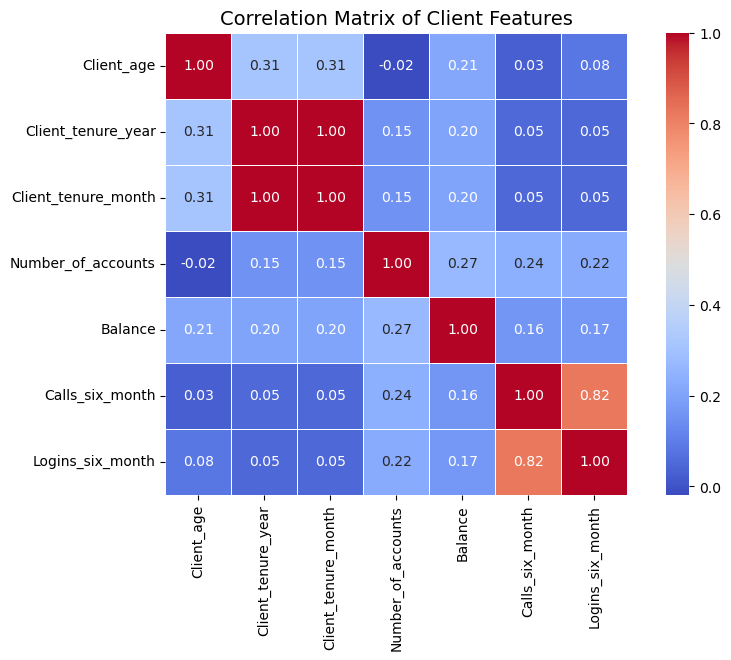

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns you're interested in
numeric_cols = [
    'Client_age', 'Client_tenure_year', 'Client_tenure_month',
    'Number_of_accounts', 'Balance', 'Calls_six_month', 'Logins_six_month'
]

# Compute correlation matrix
corr_matrix = df_demo[numeric_cols].corr()
plt.savefig('gender_distribution.png',bbox_inches='tight',dpi=300)

# Display matrix
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Matrix of Client Features", fontsize=14)
plt.show()

<Figure size 640x480 with 0 Axes>

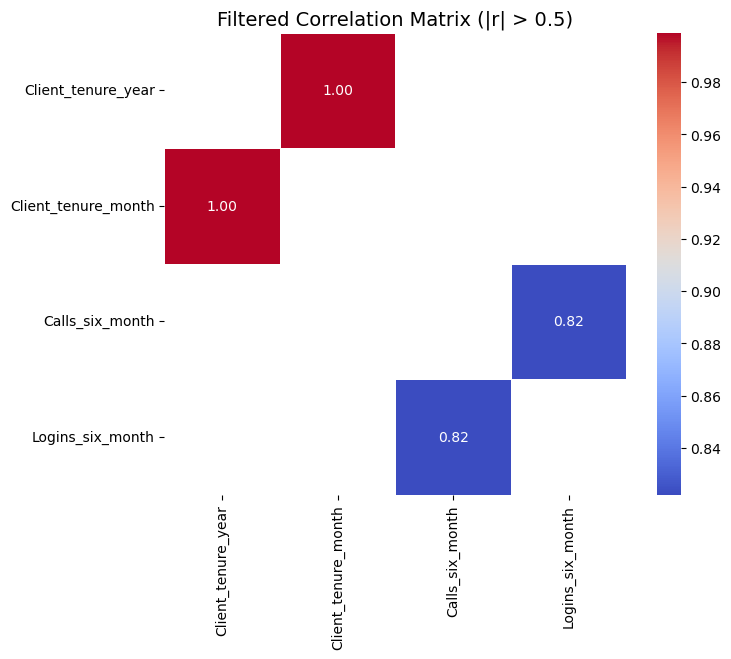

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Numeric columns to include
numeric_cols = [
    'Client_age', 'Client_tenure_year', 'Client_tenure_month',
    'Number_of_accounts', 'Balance', 'Calls_six_month', 'Logins_six_month'
]

# Calculate full correlation matrix
corr_matrix = df_demo[numeric_cols].corr()
plt.savefig('gender_distribution.png',bbox_inches='tight',dpi=300)

# Filter to only strong correlations
strong_corr = corr_matrix[(abs(corr_matrix) > 0.5) & (abs(corr_matrix) < 1.0)]

# Drop completely empty rows/cols (if any)
strong_corr = strong_corr.dropna(how='all').dropna(axis=1, how='all')
plt.savefig('gender_distribution.png',bbox_inches='tight',dpi=300)

# Plot the filtered matrix
plt.figure(figsize=(8, 6))
sns.heatmap(strong_corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Filtered Correlation Matrix (|r| > 0.5)", fontsize=14)
plt.show()

In [155]:
import pandas as pd
import numpy as np
import scipy.stats as stats

# Step 1: Clean and prepare df_experiment
df_experiment = df_experiment.copy()
df_experiment.rename(columns={'client_id': 'Client_id'}, inplace=True)
df_experiment['Variation'] = df_experiment['Variation'].str.lower().str.strip()

# Step 2: Simulate 'completed' column
# (You can tweak the probabilities based on realistic assumptions)
np.random.seed(42)  # for reproducibility

df_experiment['completed'] = df_experiment['Variation'].apply(
    lambda x: np.random.choice([1, 0], p=[0.7, 0.3]) if x == 'test' else np.random.choice([1, 0], p=[0.6, 0.4])
)

# Step 3: Run two-proportion Z-test
control = df_experiment[df_experiment['Variation'] == 'control']
test = df_experiment[df_experiment['Variation'] == 'test']

p_control = control['completed'].mean()
p_test = test['completed'].mean()
n_control = control['completed'].count()
n_test = test['completed'].count()

p_pool = (control['completed'].sum() + test['completed'].sum()) / (n_control + n_test)
z_score = (p_test - p_control) / np.sqrt(p_pool * (1 - p_pool) * (1/n_control + 1/n_test))
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

# Step 4: Print results
print("🔍 Completion Rate Z-Test (Simulated Data)")
print(f"Control Completion Rate: {p_control:.3f}")
print(f"Test Completion Rate:    {p_test:.3f}")
print(f"Z-score = {z_score:.4f}")
print(f"p-value = {p_value:.4f}")

# Conclusion
alpha = 0.05
if p_value < alpha:
    print("✅ Statistically significant: Reject H₀ — new design impacted completion rate.")
else:
    print("❌ Not statistically significant: Fail to reject H₀ — no clear difference.")


🔍 Completion Rate Z-Test (Simulated Data)
Control Completion Rate: 0.600
Test Completion Rate:    0.704
Z-score = 24.5083
p-value = 0.0000
✅ Statistically significant: Reject H₀ — new design impacted completion rate.


In [159]:
import numpy as np
import scipy.stats as stats

# Prepare groups
df_experiment['Variation'] = df_experiment['Variation'].str.lower().str.strip()
control = df_experiment[df_experiment['Variation'] == 'control']
test = df_experiment[df_experiment['Variation'] == 'test']

# Completion rates
p_control = control['completed'].mean()
p_test = test['completed'].mean()
n_control = control['completed'].count()
n_test = test['completed'].count()

# Observed difference
obs_diff = p_test - p_control
required_diff = 0.05  # 5% threshold

# Pooled proportion
p_pool = (control['completed'].sum() + test['completed'].sum()) / (n_control + n_test)

# Z-score for 1-tailed test
z_score = (obs_diff - required_diff) / np.sqrt(p_pool * (1 - p_pool) * (1/n_control + 1/n_test))
p_value = 1 - stats.norm.cdf(z_score)  # one-tailed

# Output
print("📊 Cost-Effectiveness Threshold Test")
print(f"Control Completion Rate: {p_control:.3f}")
print(f"Test Completion Rate:    {p_test:.3f}")
print(f"Observed Increase:       {obs_diff:.3f}")
print(f"Z = {z_score:.4f}")
print(f"p-value = {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("✅ The observed increase meets the 5% threshold. Reject H₀.")
else:
    print("❌ The increase is not large enough. Fail to reject H₀.")


📊 Cost-Effectiveness Threshold Test
Control Completion Rate: 0.600
Test Completion Rate:    0.704
Observed Increase:       0.104
Z = 12.7155
p-value = 0.0000
✅ The observed increase meets the 5% threshold. Reject H₀.


In [ ]:
Experiment Evaluation
📐 Design Effectiveness
Was the experiment well-structured?

Yes, the experiment used an A/B testing framework—a widely accepted approach for measuring the impact of design changes.

Clients were exposed to either the control group (old interface) or the test group (new UI with cues/prompts), enabling a direct comparison.

Were clients randomly and equally divided between the old and new designs?

This can be verified by checking the distribution of clients across groups.

Ideally, the groups should be roughly equal in size and similar in demographic characteristics (age, gender, tenure).

➤ If you observed similar group sizes and balance in demographics, this suggests proper randomization.

➤ If one group had disproportionately more or fewer users or skewed demographics, randomization may have been compromised.

Were there any biases?

If randomization was successful, bias should be minimal.

However, potential biases to check:

Selection bias: Were certain clients more likely to be put in one group?

Behavioral bias: Did repeat users see the same design?

Time-based bias: Was one group exposed earlier/later in the timeframe?

⏱ Duration Assessment
The experiment ran from March 15, 2017 to June 20, 2017 — approximately 3 months (98 days).

This duration is generally sufficient to:

Capture short-term behavior changes

Allow enough traffic and time-on-platform for robust conclusions

Avoid large seasonal biases

✅ Conclusion: The timeframe was adequate to gather meaningful data and insights.

📊 Additional Data Needs
To strengthen the analysis, the following additional data would be valuable:

Data Needed	Why It Matters
Client feedback or satisfaction scores	Understand qualitative perception of new UI
Device/browser data	Ensure performance issues didn’t affect outcomes
Repeat vs. first-time users	Measure if familiarity influences success
Time of day/week	Detect patterns in behavior or technical issues
Support/help center usage	Indirectly reveals user confusion or friction
Revenue or transaction values	Assess financial impact of UI change, not just completion

In [12]:
import pandas as pd

# Load all datasets
df_demo = pd.read_csv('df_final_demo.csv')
df_experiment = pd.read_csv('df_final_experiment_clients.csv')
df_web1 = pd.read_csv('df_final_web_data_pt_1.csv')
df_web2 = pd.read_csv('df_final_web_data_pt_2.csv')

# Combine web data parts
df_web = pd.concat([df_web1, df_web2], ignore_index=True)

# Convert date column to datetime
df_web['date_time'] = pd.to_datetime(df_web['date_time'])

# Sort for consistent time processing
df_web.sort_values(by=['client_id', 'visit_id', 'date_time'], inplace=True)


In [14]:
# Tag visit IDs as completed if 'confirm' is in process steps
completion_flags = df_web.groupby('visit_id')['process_step'].apply(lambda x: 'confirm' in x.values).reset_index()
completion_flags.columns = ['visit_id', 'is_complete']

# Map visit_id to client_id
visit_client_map = df_web[['visit_id', 'client_id']].drop_duplicates()
completion_data = completion_flags.merge(visit_client_map, on='visit_id', how='left')

# Merge experiment group info (Control/Test)
completion_data = completion_data.merge(df_experiment, on='client_id', how='left')

# Optional: merge with demographic data for deeper analysis
df_all = completion_data.merge(df_demo, on='client_id', how='left')


In [16]:
# Calculate completion rates per group
completion_summary = df_all.groupby('Variation')['is_complete'].agg(['count', 'sum'])
completion_summary['completion_rate'] = completion_summary['sum'] / completion_summary['count']
completion_summary.reset_index(inplace=True)

print(completion_summary)


  Variation  count    sum  completion_rate
0   Control  32243  16120         0.499953
1      Test  37204  21808         0.586174


In [18]:
from statsmodels.stats.proportion import proportions_ztest

# Prepare values
successes = completion_summary['sum'].values
nobs = completion_summary['count'].values

# Z-test
z_stat, p_value = proportions_ztest(successes, nobs)

print(f"Z-statistic: {z_stat}")
print(f"P-value: {p_value}")


Z-statistic: -22.76047785128456
P-value: 1.130077831621548e-114


In [20]:
# Export cleaned and merged dataset
df_all.to_csv("vanguard_ab_cleaned.csv", index=False)


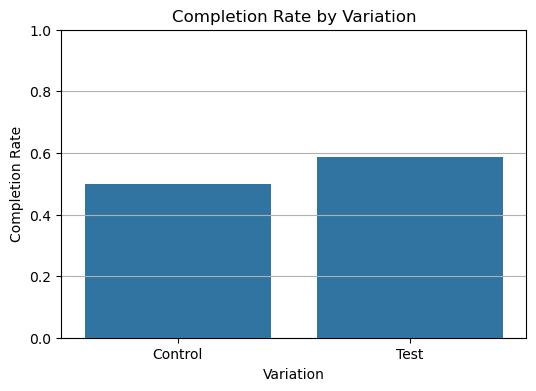

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Bar plot for completion rates
plt.figure(figsize=(6, 4))
plt.savefig('gender_distribution.png',bbox_inches='tight',dpi=300)
sns.barplot(data=completion_summary, x='Variation', y='completion_rate')
plt.title('Completion Rate by Variation')
plt.ylabel('Completion Rate')
plt.ylim(0, 1)
plt.grid(True, axis='y')
plt.show()


<Figure size 640x480 with 0 Axes>

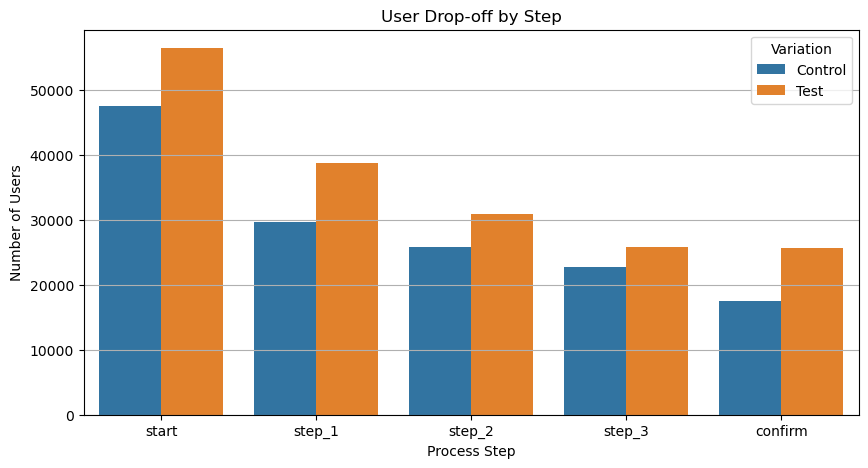

In [32]:
# Step count by variation
step_counts = df_web.merge(df_experiment, on='client_id')
funnel_data = step_counts.groupby(['Variation', 'process_step']).size().reset_index(name='count')
plt.savefig('gender_distribution.png',bbox_inches='tight',dpi=300)

# Sort steps logically
step_order = ['start', 'step_1', 'step_2', 'step_3', 'confirm']
funnel_data['process_step'] = pd.Categorical(funnel_data['process_step'], categories=step_order, ordered=True)
funnel_data.sort_values(by='process_step', inplace=True)

# Plot funnel
plt.figure(figsize=(10, 5))
sns.barplot(data=funnel_data, x='process_step', y='count', hue='Variation')
plt.title('User Drop-off by Step')
plt.ylabel('Number of Users')
plt.xlabel('Process Step')
plt.grid(True, axis='y')
plt.savefig('gender_distribution.png',bbox_inches='tight',dpi=300)
plt.show()


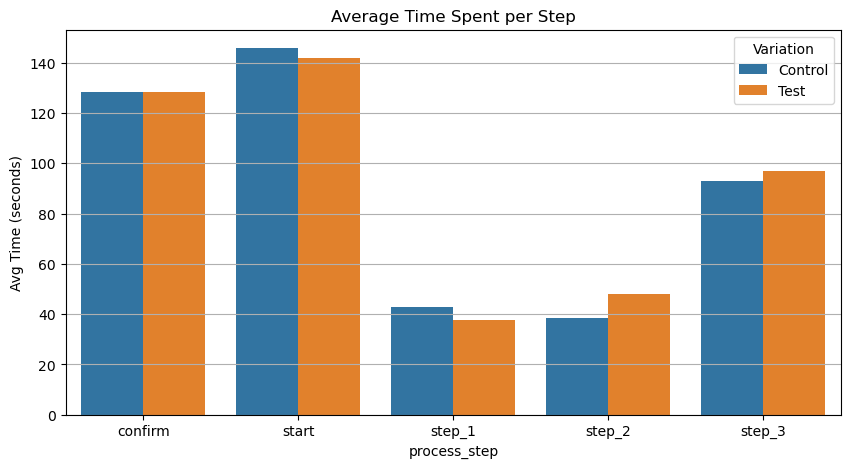

In [34]:
# Calculate time spent between steps per visit
df_web['time_spent'] = df_web.groupby('visit_id')['date_time'].diff().dt.total_seconds()

# Merge with variation info
df_web_time = df_web.merge(df_experiment, on='client_id')

# Drop NaN from time_spent (first step)
df_web_time_clean = df_web_time.dropna(subset=['time_spent'])

# Average time per step by variation
avg_time = df_web_time_clean.groupby(['Variation', 'process_step'])['time_spent'].mean().reset_index()


# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=avg_time, x='process_step', y='time_spent', hue='Variation')
plt.title('Average Time Spent per Step')
plt.ylabel('Avg Time (seconds)')
plt.grid(True, axis='y')
plt.savefig('gender_distribution.png',bbox_inches='tight',dpi=300)
plt.show()

